<a href="https://colab.research.google.com/github/leonardeugenia-hash/TGF2026/blob/main/analisis_del_dato/analisis5_regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Script 5 — Regresión Lineal y Regresión Logística
**Input:** `dataset_canciones_clusters.csv` (output del Script 4)  
**Output:** `resultados_regresion.csv`, `metricas_regresion.csv`


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42
ANIO_CORTE   = 2020   # Train: ≤2020 | Test: 2021-2024

COLORES_BASE = ['steelblue', 'tomato', 'mediumseagreen', 'darkorange',
                'mediumpurple', 'goldenrod', 'slategray']

try:
    df = pd.read_csv('dataset_canciones_clusters.csv')
    print('Leyendo dataset_canciones_clusters.csv (con clusters del Script 4)')
except FileNotFoundError:
    df = pd.read_csv('dataset_canciones_limpio.csv')
    print('Leyendo dataset_canciones_limpio.csv (Script 3 — sin clusters)')

print(f'Shape: {df.shape}')
print(f'Años disponibles: {sorted(df["year"].unique())}')
print(f'Nulos: {df.isnull().sum().sum()}')
df.head()

Leyendo dataset_canciones_clusters.csv (con clusters del Script 4)
Shape: (1185, 17)
Años disponibles: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Nulos: 482


,year,track_id,track_name,artist_name,album_name,release_date,release_year,explicit,popularity,duration_sec,artist_popularity,artist_genres,duration_min,release_month,years_since_release,genre_group,cluster
0,2010,2yc9sElleYDl3NXMZSgsRv,Blanco y Negro,Malú,Guerra Fria,2010-05-08,2010,0,58,233.666,60,"flamenco pop, flamenco",3.894433,5.0,0,flamenco pop,1
1,2010,7bp62Lo0nOBcfB70iUoibE,Barbie de extrarradio,Melendi,Volvamos a empezar (Deluxe edition),2010-10-29,2010,0,65,215.946,73,"flamenco, flamenco pop",3.599100,10.0,0,flamenco,0
2,2010,4PHX6bpHDxiR9RGzAKWcyk,Cuando Me Enamoro,Enrique Iglesias,Euphoria,NaN,2010,0,78,200.586,78,"latin pop, latin",3.343100,NaN,0,latin pop,0
3,2010,33LvyB8v3LELoM4NKL2WKB,Mira la Vida,Dani Martín,Pequeño,2010-10-26,2010,0,46,221.013,63,NaN,3.683550,10.0,0,unknown,1
4,2010,75hfPTtNhiqUglKXIVOaju,Sonrisa,Ana Torroja,Sonrisa,2010-09-14,2010,0,40,259.040,59,latin pop,4.317333,9.0,0,latin pop,1


---
## 1. Preparación de datos — Split temporal



In [ ]:
TARGET_REG = 'popularity'

# variable binaria: alta popularidad (top 25% global)
umbral_top = df[TARGET_REG].quantile(0.75)
df['alta_popularidad'] = (df[TARGET_REG] >= umbral_top).astype(int)

print(f'Umbral alta popularidad (percentil 75): {umbral_top:.1f}')
print(f'Canciones alta popularidad: {df["alta_popularidad"].sum()} ({df["alta_popularidad"].mean():.1%})')
print(f'Canciones baja popularidad: {(df["alta_popularidad"]==0).sum()} ({(df["alta_popularidad"]==0).mean():.1%})')

# features
cols_excluir_feat = [
    'track_name', 'artist_name', 'artist_genres', 'release_date',
    'genre_group', 'genre_group_agrupado', 'dominant_genre',
    'popularity', 'alta_popularidad',
    'cluster', 'dist_to_centroid',
    'temporada_lanzamiento', 'decada_lanzamiento', 'year'
]

feature_cols = [c for c in df.columns if c not in cols_excluir_feat
                and df[c].dtype in ['int64', 'float64', 'int32', 'float32', 'bool', 'uint8']]

print(f'\nFeatures seleccionadas ({len(feature_cols)}):')
print(feature_cols)

df_model = df[feature_cols + [TARGET_REG, 'alta_popularidad', 'year']].dropna()
df_model = df_model.sort_values('year').reset_index(drop=True)
print(f'\nFilas para modelado: {len(df_model)} (de {len(df)})')

# split temporal
train_mask = df_model['year'] <= ANIO_CORTE
test_mask  = df_model['year'] >  ANIO_CORTE

X_train = df_model.loc[train_mask, feature_cols]
X_test  = df_model.loc[test_mask,  feature_cols]
y_reg_train = df_model.loc[train_mask, TARGET_REG]
y_reg_test  = df_model.loc[test_mask,  TARGET_REG]
y_clf_train = df_model.loc[train_mask, 'alta_popularidad']
y_clf_test  = df_model.loc[test_mask,  'alta_popularidad']

print(f'\nSplit temporal (corte en {ANIO_CORTE}):')
print(f'  Train: {len(X_train)} canciones ({df_model.loc[train_mask, "year"].min()}–{ANIO_CORTE})')
print(f'  Test:  {len(X_test)} canciones  ({ANIO_CORTE+1}–{df_model["year"].max()})')
print(f'  Proporción alta popularidad — Train: {y_clf_train.mean():.1%} | Test: {y_clf_test.mean():.1%}')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Umbral alta popularidad (percentil 75): 70.0
Canciones alta popularidad: 300 (25.3%)
Canciones baja popularidad: 885 (74.7%)

Features seleccionadas (7):
['release_year', 'explicit', 'duration_sec', 'artist_popularity', 'duration_min', 'release_month', 'years_since_release']

Filas para modelado: 1175 (de 1185)

Split temporal (corte en 2020):
  Train: 818 canciones (2010–2020)
  Test:  357 canciones  (2021–2024)
  Proporción alta popularidad — Train: 19.2% | Test: 38.7%


---
## 2. MODELO A — Regresión Lineal (línea base)

In [ ]:
# entrenamiento
lr = LinearRegression()
lr.fit(X_train_sc, y_reg_train)

# predicciones
y_pred_lr = lr.predict(X_test_sc)

# métricas test
mae_lr  = mean_absolute_error(y_reg_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_reg_test, y_pred_lr))
r2_lr   = r2_score(y_reg_test, y_pred_lr)

# validación cruzada con TimeSeriesSplit (respeta orden cronológico)
tscv = TimeSeriesSplit(n_splits=5)
cv_mae_lr = -cross_val_score(LinearRegression(), X_train_sc, y_reg_train,
                              cv=tscv, scoring='neg_mean_absolute_error')

print('=' * 55)
print('MODELO A — REGRESIÓN LINEAL')
print('=' * 55)
print(f'MAE  (test temporal):   {mae_lr:.3f} puntos de popularidad')
print(f'RMSE (test temporal):   {rmse_lr:.3f}')
print(f'R²   (test temporal):   {r2_lr:.4f}')
print(f'MAE  (TimeSeriesSplit): {cv_mae_lr.mean():.3f} ± {cv_mae_lr.std():.3f}')

coef_lr = pd.DataFrame({
    'Feature': feature_cols,
    'Coeficiente': lr.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print(f'\nTop 10 predictores más influyentes:')
print(coef_lr.head(10).to_string(index=False))

MODELO A — REGRESIÓN LINEAL
MAE  (test temporal):   8.271 puntos de popularidad
RMSE (test temporal):   10.684
R²   (test temporal):   0.2469
MAE  (TimeSeriesSplit): 11.398 ± 2.041

Top 10 predictores más influyentes:
            Feature  Coeficiente
  artist_popularity    14.498424
           explicit     0.525799
years_since_release     0.323495
      release_month    -0.249468
       release_year     0.085932
       duration_sec     0.047522
       duration_min     0.047522


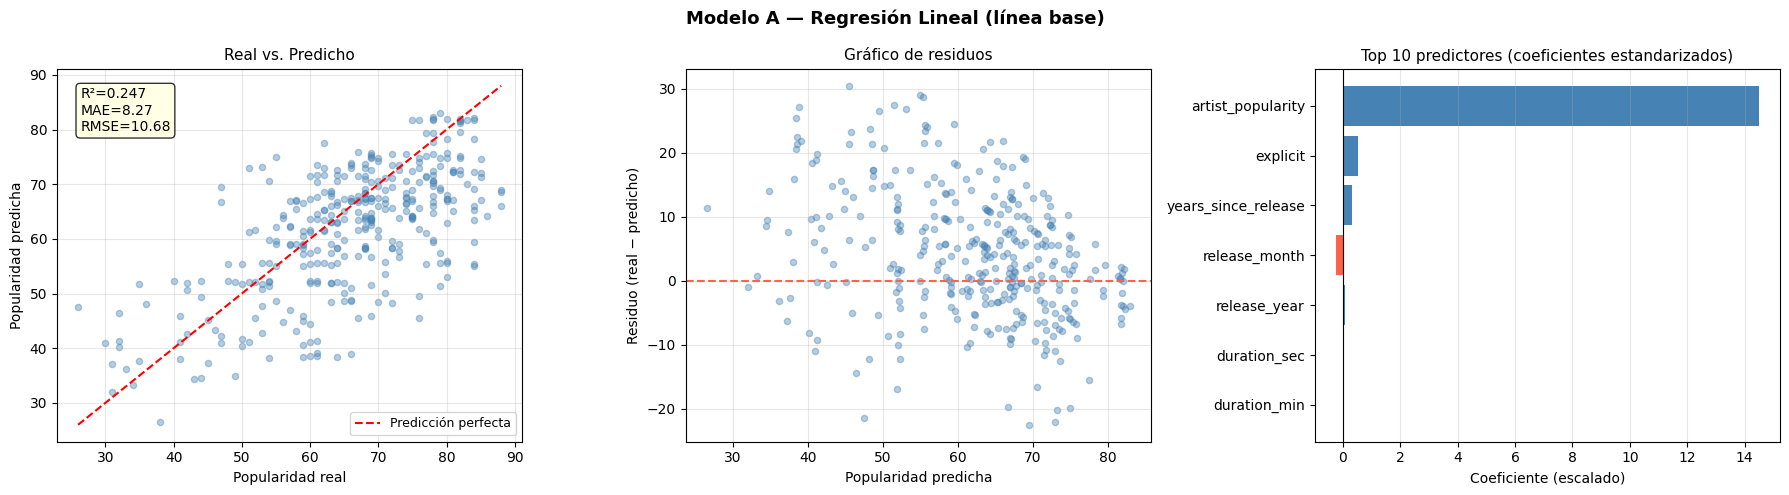

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Modelo A — Regresión Lineal (línea base)', fontsize=13, fontweight='bold')

# real vs. Predicho
axes[0].scatter(y_reg_test, y_pred_lr, alpha=0.4, color='steelblue', s=20)
lim = [y_reg_test.min(), y_reg_test.max()]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_title('Real vs. Predicho', fontsize=11)
axes[0].set_xlabel('Popularidad real')
axes[0].set_ylabel('Popularidad predicha')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].text(0.05, 0.95, f'R²={r2_lr:.3f}\nMAE={mae_lr:.2f}\nRMSE={rmse_lr:.2f}',
             transform=axes[0].transAxes, fontsize=10, va='top',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# residuos
residuos = y_reg_test - y_pred_lr
axes[1].scatter(y_pred_lr, residuos, alpha=0.4, color='steelblue', s=20)
axes[1].axhline(0, color='tomato', linestyle='--', linewidth=1.5)
axes[1].set_title('Gráfico de residuos', fontsize=11)
axes[1].set_xlabel('Popularidad predicha')
axes[1].set_ylabel('Residuo (real − predicho)')
axes[1].grid(alpha=0.3)

# top 10 coeficientes
top_coef = coef_lr.head(10)
colores_coef = ['steelblue' if v > 0 else 'tomato' for v in top_coef['Coeficiente']]
axes[2].barh(top_coef['Feature'][::-1], top_coef['Coeficiente'][::-1], color=colores_coef[::-1])
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Top 10 predictores (coeficientes estandarizados)', fontsize=11)
axes[2].set_xlabel('Coeficiente (escalado)')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. MODELO B — Regresión Logística (avanzado)

In [ ]:
# entrenamiento con regularización L2 (default, C=1.0)
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=1.0)
log_reg.fit(X_train_sc, y_clf_train)

# predicciones
y_pred_clf = log_reg.predict(X_test_sc)
y_prob_clf = log_reg.predict_proba(X_test_sc)[:, 1]

# métricas test
acc_log = accuracy_score(y_clf_test, y_pred_clf)
f1_log  = f1_score(y_clf_test, y_pred_clf)
auc_log = roc_auc_score(y_clf_test, y_prob_clf)

# validación cruzada con TimeSeriesSplit (mismo esquema que Modelo A)
cv_f1_log = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_train_sc, y_clf_train,
    cv=TimeSeriesSplit(n_splits=5), scoring='f1'
)

print('=' * 55)
print('MODELO B — REGRESIÓN LOGÍSTICA')
print('=' * 55)
print(f'Accuracy  (test temporal):   {acc_log:.4f}  ({acc_log:.1%})')
print(f'F1-Score  (test temporal):   {f1_log:.4f}')
print(f'AUC-ROC   (test temporal):   {auc_log:.4f}')
print(f'F1 (TimeSeriesSplit):        {cv_f1_log.mean():.4f} ± {cv_f1_log.std():.4f}')
print(f'\nReporte de clasificación:')
print(classification_report(y_clf_test, y_pred_clf, target_names=['Baja pop.', 'Alta pop.']))

MODELO B — REGRESIÓN LOGÍSTICA
Accuracy  (test temporal):   0.6751  (67.5%)
F1-Score  (test temporal):   0.5672
AUC-ROC   (test temporal):   0.7632
F1 (TimeSeriesSplit):        0.4056 ± 0.2804

Reporte de clasificación:
              precision    recall  f1-score   support

   Baja pop.       0.73      0.75      0.74       219
   Alta pop.       0.58      0.55      0.57       138

    accuracy                           0.68       357
   macro avg       0.66      0.65      0.65       357
weighted avg       0.67      0.68      0.67       357



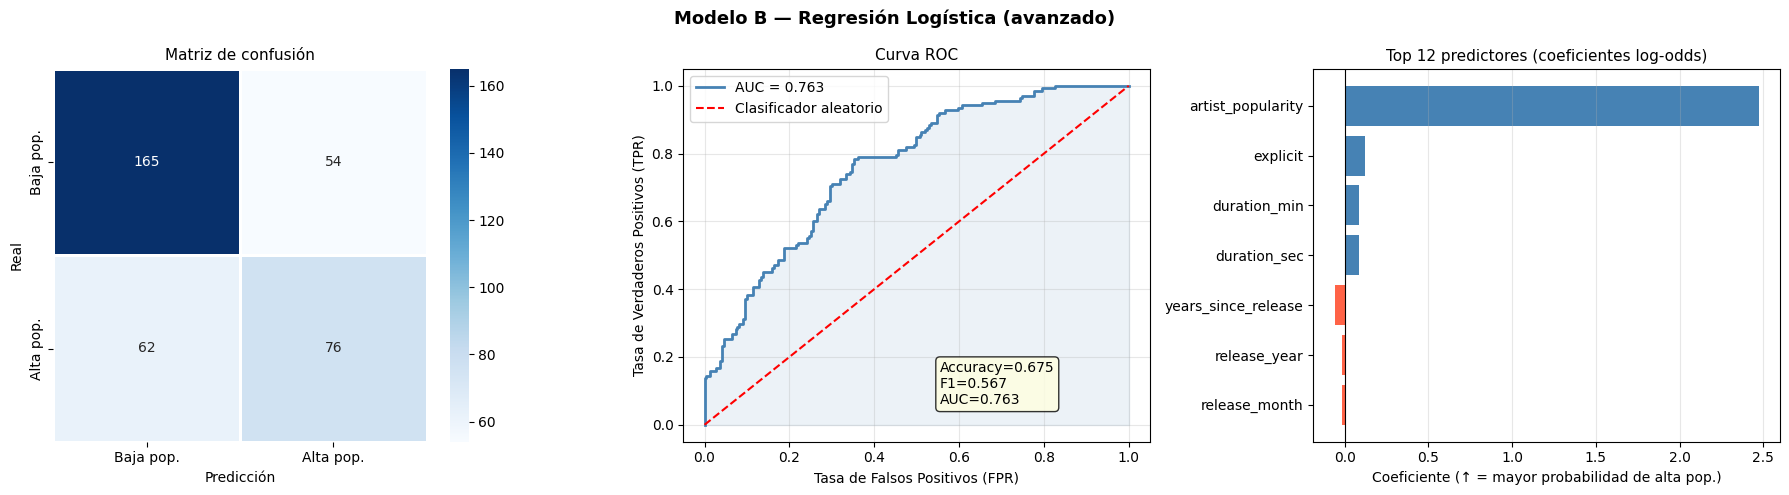

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Modelo B — Regresión Logística (avanzado)', fontsize=13, fontweight='bold')

# matriz de confusión
cm_matrix = confusion_matrix(y_clf_test, y_pred_clf)
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baja pop.', 'Alta pop.'],
            yticklabels=['Baja pop.', 'Alta pop.'],
            ax=axes[0], linewidths=1)
axes[0].set_title('Matriz de confusión', fontsize=11)
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# curva ROC
fpr, tpr, _ = roc_curve(y_clf_test, y_prob_clf)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc_log:.3f}')
axes[1].plot([0, 1], [0, 1], 'r--', lw=1.5, label='Clasificador aleatorio')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_title('Curva ROC', fontsize=11)
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].text(0.55, 0.1, f'Accuracy={acc_log:.3f}\nF1={f1_log:.3f}\nAUC={auc_log:.3f}',
             transform=axes[1].transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# coeficientes top 12
coef_clf = pd.DataFrame({
    'Feature': feature_cols,
    'Coeficiente': log_reg.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False).head(12)

colores_clf = ['steelblue' if v > 0 else 'tomato' for v in coef_clf['Coeficiente']]
axes[2].barh(coef_clf['Feature'][::-1], coef_clf['Coeficiente'][::-1], color=colores_clf[::-1])
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Top 12 predictores (coeficientes log-odds)', fontsize=11)
axes[2].set_xlabel('Coeficiente (↑ = mayor probabilidad de alta pop.)')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. COMPARACIÓN DE MODELOS A vs. B

COMPARACIÓN FINAL: MODELO A vs. MODELO B
Métrica                        Reg. Lineal (A) Reg. Logística (B)
-----------------------------------------------------------------
Accuracy                                0.7003             0.6751
F1-Score                                0.5328             0.5672
AUC-ROC                                 0.7714             0.7632

MAE (regresión continua)                 8.271                N/A
RMSE (regresión continua)               10.684                N/A
R² (regresión continua)                 0.2469                N/A


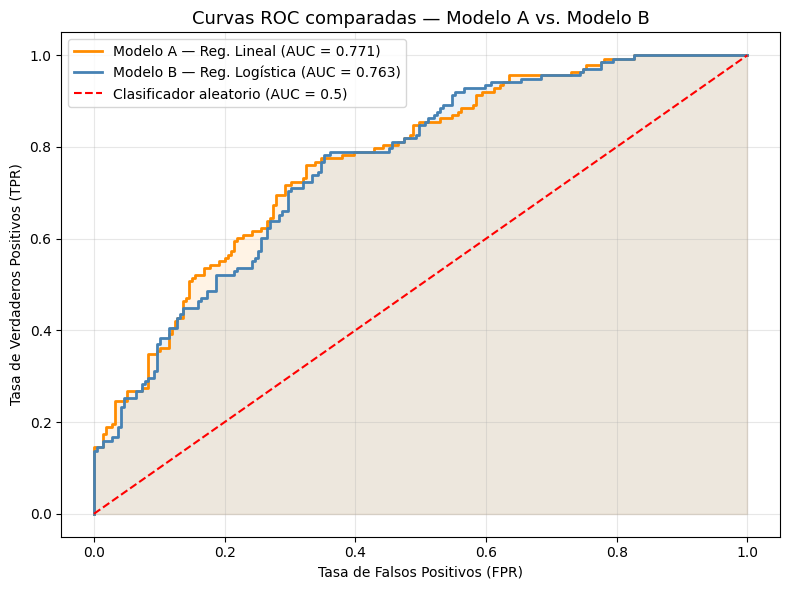

In [ ]:
# proyectamos regresión lineal al espacio de clasificación para comparar en terreno común
y_pred_lr_clf = (y_pred_lr >= umbral_top).astype(int)

acc_lr_clf = accuracy_score(y_clf_test, y_pred_lr_clf)
f1_lr_clf  = f1_score(y_clf_test, y_pred_lr_clf)
auc_lr_clf = roc_auc_score(y_clf_test, y_pred_lr)

print('=' * 65)
print('COMPARACIÓN FINAL: MODELO A vs. MODELO B')
print('=' * 65)
print(f'{"Métrica":<30} {"Reg. Lineal (A)":>15} {"Reg. Logística (B)":>18}')
print('-' * 65)
print(f'{"Accuracy":<30} {acc_lr_clf:>15.4f} {acc_log:>18.4f}')
print(f'{"F1-Score":<30} {f1_lr_clf:>15.4f} {f1_log:>18.4f}')
print(f'{"AUC-ROC":<30} {auc_lr_clf:>15.4f} {auc_log:>18.4f}')
print()
print(f'{"MAE (regresión continua)":<30} {mae_lr:>15.3f} {"N/A":>18}')
print(f'{"RMSE (regresión continua)":<30} {rmse_lr:>15.3f} {"N/A":>18}')
print(f'{"R² (regresión continua)":<30} {r2_lr:>15.4f} {"N/A":>18}')

# curvas ROC comparadas
fig, ax = plt.subplots(figsize=(8, 6))
fpr_a, tpr_a, _ = roc_curve(y_clf_test, y_pred_lr)
fpr_b, tpr_b, _ = roc_curve(y_clf_test, y_prob_clf)

ax.plot(fpr_a, tpr_a, color='darkorange', lw=2,
        label=f'Modelo A — Reg. Lineal (AUC = {auc_lr_clf:.3f})')
ax.plot(fpr_b, tpr_b, color='steelblue', lw=2,
        label=f'Modelo B — Reg. Logística (AUC = {auc_log:.3f})')
ax.plot([0, 1], [0, 1], 'r--', lw=1.5, label='Clasificador aleatorio (AUC = 0.5)')
ax.fill_between(fpr_b, tpr_b, alpha=0.1, color='steelblue')
ax.fill_between(fpr_a, tpr_a, alpha=0.1, color='darkorange')
ax.set_title('Curvas ROC comparadas — Modelo A vs. Modelo B', fontsize=13)
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. INTERPRETACIÓN Y CONCLUSIONES

In [ ]:
# comparación de coeficientes entre modelos
coef_df_final = pd.DataFrame({
    'Feature': feature_cols,
    'Coef_RegLineal': lr.coef_,
    'Coef_RegLogistica': log_reg.coef_[0]
})
coef_df_final['Efecto_en_popularidad'] = coef_df_final['Coef_RegLogistica'].apply(
    lambda x: '↑ favorece alta pop.' if x > 0.1 else ('↓ reduce prob. alta pop.' if x < -0.1 else '≈ neutro')
)

top_positivos = coef_df_final.nlargest(5, 'Coef_RegLogistica')
top_negativos = coef_df_final.nsmallest(5, 'Coef_RegLogistica')

print('Variables que más FAVORECEN alta popularidad (Reg. Logística):')
print(top_positivos[['Feature', 'Coef_RegLogistica']].to_string(index=False))
print('\nVariables que más REDUCEN probabilidad de alta popularidad:')
print(top_negativos[['Feature', 'Coef_RegLogistica']].to_string(index=False))



Variables que más FAVORECEN alta popularidad (Reg. Logística):
          Feature  Coef_RegLogistica
artist_popularity           2.473449
         explicit           0.123379
     duration_min           0.088526
     duration_sec           0.088526
    release_month          -0.018190

Variables que más REDUCEN probabilidad de alta popularidad:
            Feature  Coef_RegLogistica
years_since_release          -0.059891
       release_year          -0.018693
      release_month          -0.018190
       duration_sec           0.088526
       duration_min           0.088526


---
## 6. GUARDADO

In [ ]:
coef_df_final.to_csv('resultados_regresion.csv', index=False)
print('✅ resultados_regresion.csv guardado')

metricas = pd.DataFrame({
    'Modelo':    ['Regresión Lineal (A)', 'Regresión Logística (B)'],
    'Split':     ['Temporal (corte 2020)', 'Temporal (corte 2020)'],
    'CV':        ['TimeSeriesSplit (5 folds)', 'TimeSeriesSplit (5 folds)'],
    'MAE':       [round(mae_lr, 3),    '—'],
    'RMSE':      [round(rmse_lr, 3),   '—'],
    'R²':        [round(r2_lr, 4),     '—'],
    'Accuracy':  [round(acc_lr_clf, 4), round(acc_log, 4)],
    'F1-Score':  [round(f1_lr_clf, 4),  round(f1_log, 4)],
    'AUC-ROC':   [round(auc_lr_clf, 4), round(auc_log, 4)],
})
metricas.to_csv('metricas_regresion.csv', index=False)
print('✅ metricas_regresion.csv guardado')

metricas.set_index('Modelo').style \
    .background_gradient(cmap='Blues', subset=['Accuracy', 'F1-Score', 'AUC-ROC']) \
    .set_caption('Resumen de métricas — Regresión Lineal vs. Regresión Logística (split temporal)') \
    .set_table_styles([
        {'selector': 'th.col_heading',
         'props': [('background-color', '#1a3a5c'), ('color', 'white'),
                   ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'th.row_heading',
         'props': [('background-color', '#1a3a5c'), ('color', 'white'),
                   ('font-weight', 'bold')]},
        {'selector': 'th.blank, th.index_name',
         'props': [('background-color', '#1a3a5c'), ('color', 'white'),
                   ('font-weight', 'bold')]},
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('padding-bottom', '8px'), ('text-align', 'center')]}
    ])

✅ resultados_regresion.csv guardado
✅ metricas_regresion.csv guardado


,Split,CV,MAE,RMSE,R²,Accuracy,F1-Score,AUC-ROC
Modelo,,,,,,,,
Regresión Lineal (A),Temporal (corte 2020),TimeSeriesSplit (5 folds),8.271000,10.684000,0.246900,0.700300,0.532800,0.771400
Regresión Logística (B),Temporal (corte 2020),TimeSeriesSplit (5 folds),—,—,—,0.675100,0.567200,0.763200
